Importing Packages and Uploading Dataset

In [24]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

##Uploading Dataset##
file_path = "/Users/oliviadittrich/Desktop/Spring 2026/FIM 601/Project/Data/Final_Mean_Data.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

print(df.head())

        Date  PX_LAST
0 2022-12-30  3839.50
1 2023-01-03  3824.14
2 2023-01-04  3852.97
3 2023-01-05  3808.10
4 2023-01-06  3895.08


Check Column Names and Plotting Price Levels

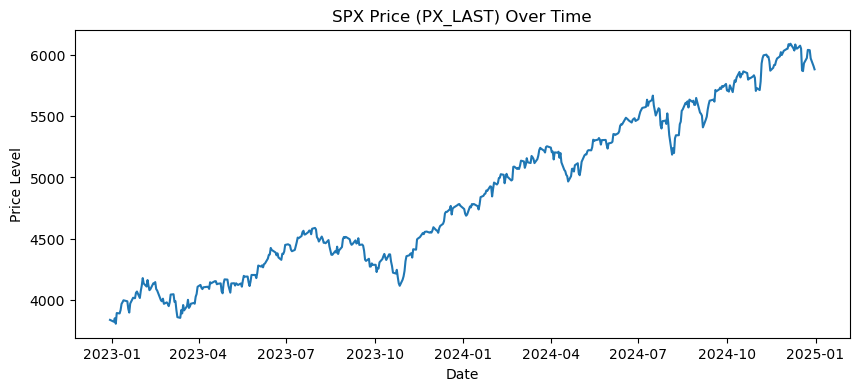

In [25]:
##Check column names##
df.columns
import pandas as pd
import numpy as np

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").copy()

##Plotting Price Levels##
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["PX_LAST"])
plt.title("SPX Price (PX_LAST) Over Time")
plt.xlabel("Date")
plt.ylabel("Price Level")
plt.show()


Calculating Log Returns and Dropping NaN Value

In [26]:
##Calculating Log Returns##
df["log_return"] = np.log(df["PX_LAST"]) - np.log(df["PX_LAST"].shift(1))

## Dropping 12/30 is NaN because there is no previous day to compare to for the log return calculation.##
df = df.dropna(subset=["log_return"])

ADF Test on Log Returns

In [27]:
## Run ADF test on log returns to check for stationarity ##
adf_result = adfuller(df["log_return"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations:", adf_result[3])
print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")
if adf_result[1] < 0.05:
    print("\nConclusion: Reject the null hypothesis. Log returns are stationary.")
else:
    print("\nConclusion: Fail to reject the null. Log returns may be non-stationary.")

ADF Statistic: -21.596950660726662
p-value: 0.0
Number of lags used: 0
Number of observations: 501

Critical Values:
1%: -3.443470002903981
5%: -2.867326248740681
10%: -2.569851849873108

Conclusion: Reject the null hypothesis. Log returns are stationary.


Descriptive Statistics and Plot Log Returns

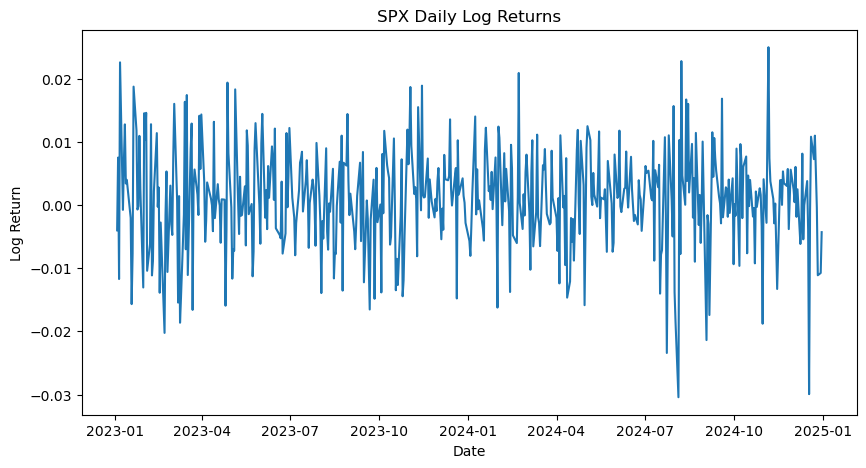

In [28]:
##Descriptive Statistics for Log Returns##
df["log_return"].describe()

##Plot Returns##
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["log_return"])
plt.title("SPX Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

Build "Data Preprocessing" Tables for Daily Returns and Daily Log Returns

Saved to: /Users/oliviadittrich/Desktop/data_preprocessing.png


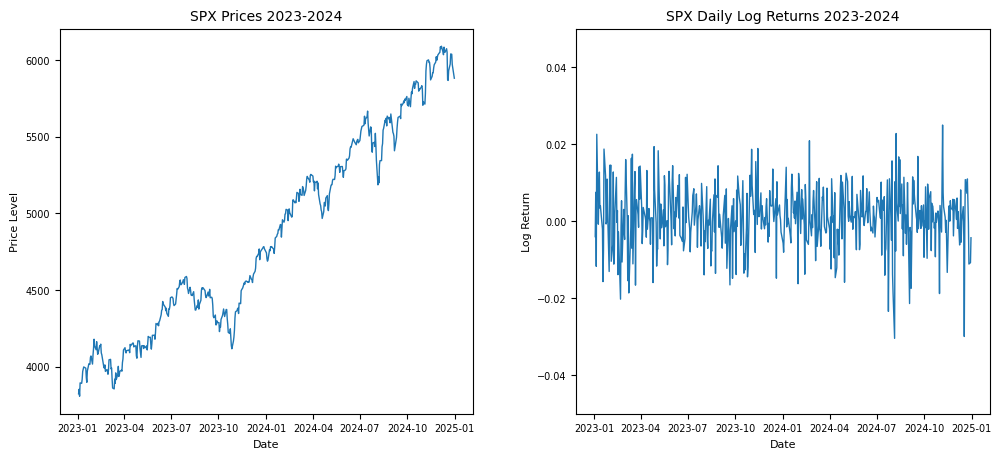

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure Date is datetime and sorted
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Create figure with more space between plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("white")

# Left plot: SPX prices
axes[0].plot(df["Date"], df["PX_LAST"], linewidth=1)
axes[0].set_title("SPX Prices 2023-2024", fontsize=10)
axes[0].set_xlabel("Date", fontsize=8)
axes[0].set_ylabel("Price Level", fontsize=8)
axes[0].tick_params(axis="x", labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)

# Right plot: daily log returns
axes[1].plot(df["Date"], df["log_return"], linewidth=1)
axes[1].set_title("SPX Daily Log Returns 2023-2024", fontsize=10)
axes[1].set_xlabel("Date", fontsize=8)
axes[1].set_ylabel("Log Return", fontsize=8)
axes[1].tick_params(axis="x", labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)
axes[1].set_ylim(-0.05, 0.05)

# Add more horizontal space between the two graphs
plt.subplots_adjust(wspace=0.25)

# Save to desktop
output_path = "/Users/oliviadittrich/Desktop/data_preprocessing.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {output_path}")

plt.show()

Squared Log Returns and Distribution of Log Returns

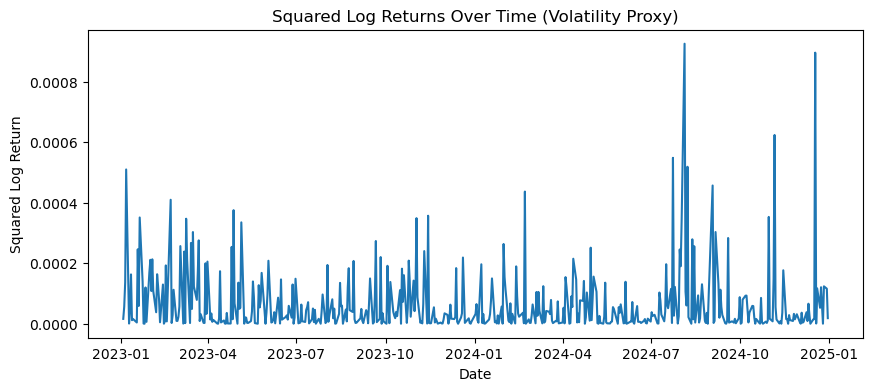

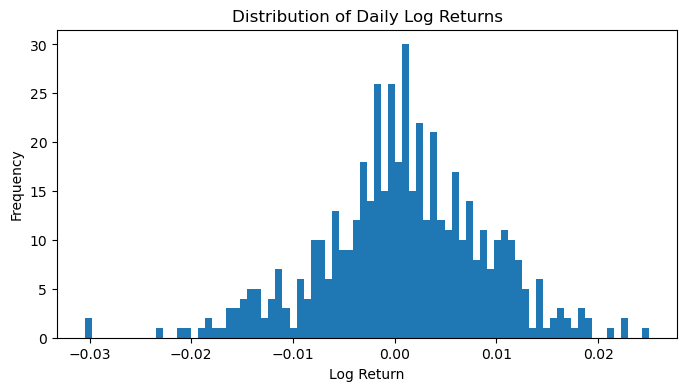

In [30]:
##Volatility Proxy: Squared Log Returns##
df["log_return_sq"] = df["log_return"]**2

plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["log_return_sq"])
plt.title("Squared Log Returns Over Time (Volatility Proxy)")
plt.xlabel("Date")
plt.ylabel("Squared Log Return")
plt.show()

##Distribution of Log Returns##
plt.figure(figsize=(8,4))
plt.hist(df["log_return"], bins=80)
plt.title("Distribution of Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

Check ACF & PACF and ACF of Squared Log Returns

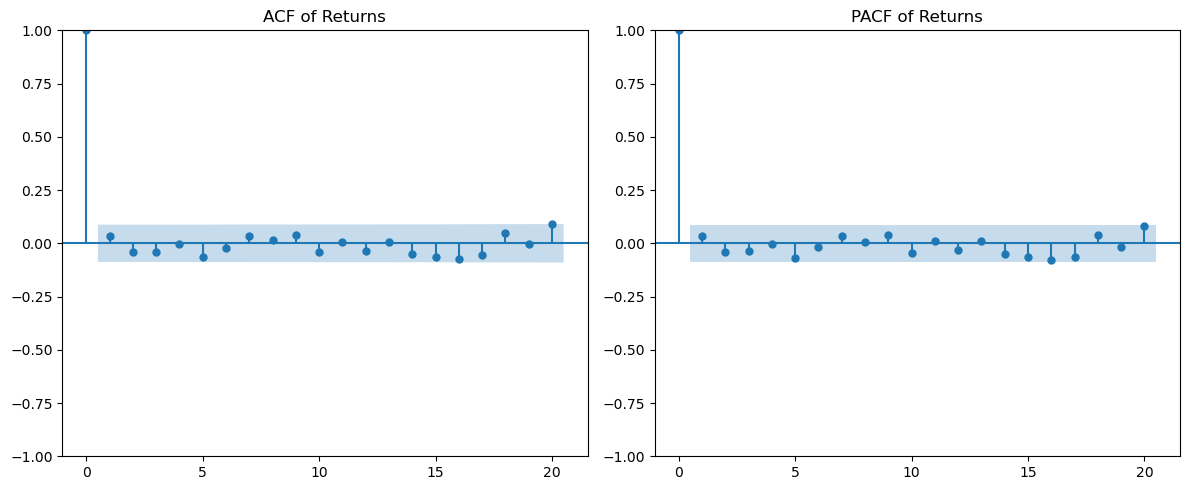

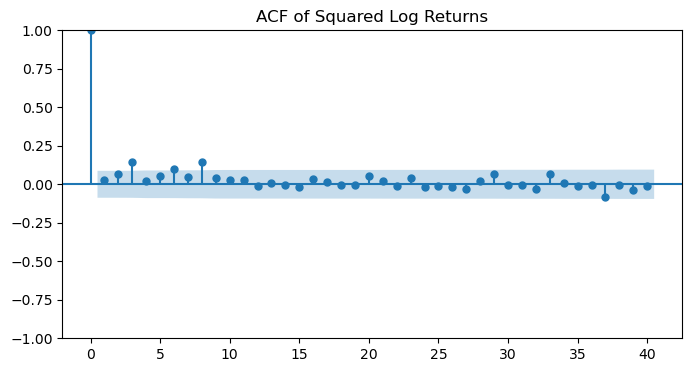

In [31]:
##Check autocorrelation (ACF & PACF)##
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df["log_return"], lags=20, ax=plt.gca())
plt.title("ACF of Returns")

plt.subplot(1,2,2)
plot_pacf(df["log_return"], lags=20, ax=plt.gca())
plt.title("PACF of Returns")

plt.tight_layout()
plt.show()

##ACF of Squared Log Returns##
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))
plot_acf(df["log_return_sq"], lags=40, ax=plt.gca())
plt.title("ACF of Squared Log Returns")
plt.show()

Build ADF Table and ACF/PACF Table

Saved to: /Users/oliviadittrich/Desktop/adf_results_chart.png


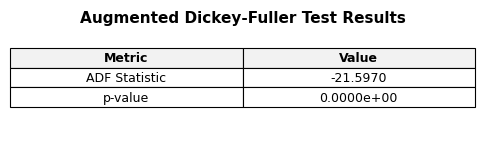

Saved to: /Users/oliviadittrich/Desktop/acf_pacf_chart.png


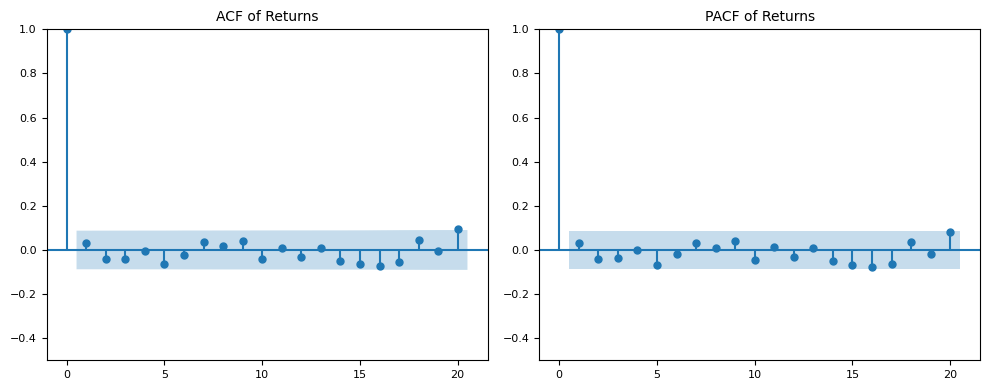

In [39]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import matplotlib.pyplot as plt

# Run ADF test
adf_result = adfuller(df["log_return"])

adf_stat = adf_result[0]
adf_pvalue = adf_result[1]

adf_table = pd.DataFrame({
    "Metric": ["ADF Statistic", "p-value"],
    "Value": [f"{adf_stat:.4f}", f"{adf_pvalue:.4e}"]
})

# Create figure
fig, ax = plt.subplots(figsize=(6, 1.8))
fig.patch.set_facecolor("white")
ax.axis("off")

# Title with less space above table
ax.text(
    0.5, 0.88,
    "Augmented Dickey-Fuller Test Results",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    transform=ax.transAxes
)

# Table
table = ax.table(
    cellText=adf_table.values,
    colLabels=adf_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

# Tighten white space above and below
plt.subplots_adjust(top=0.88, bottom=0.12)

# Save to desktop
output_path = "/Users/oliviadittrich/Desktop/adf_results_chart.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
print(f"Saved to: {output_path}")

plt.show()




from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor("white")

# ACF
plot_acf(df["log_return"], lags=20, ax=axes[0])
axes[0].set_title("ACF of Returns", fontsize=10)
axes[0].tick_params(axis="both", labelsize=8)
axes[0].set_ylim(-0.5, 1.0)

# PACF
plot_pacf(df["log_return"], lags=20, ax=axes[1])
axes[1].set_title("PACF of Returns", fontsize=10)
axes[1].tick_params(axis="both", labelsize=8)
axes[1].set_ylim(-0.5, 1.0)

plt.tight_layout()

# Save to desktop
output_path = "/Users/oliviadittrich/Desktop/acf_pacf_chart.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved to: {output_path}")

plt.show()

Fitting ARIMA Model

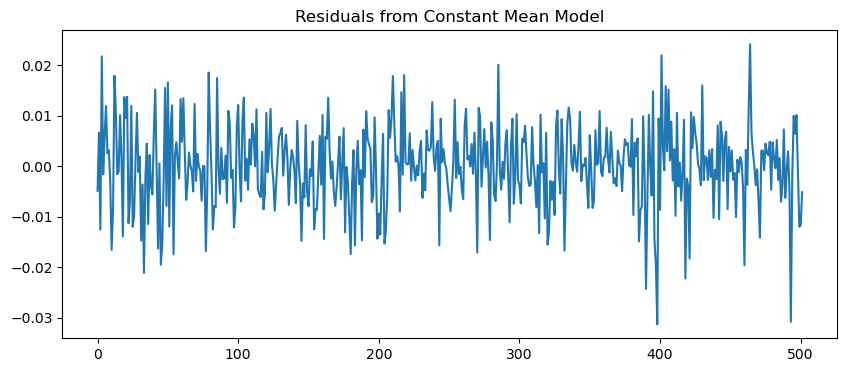

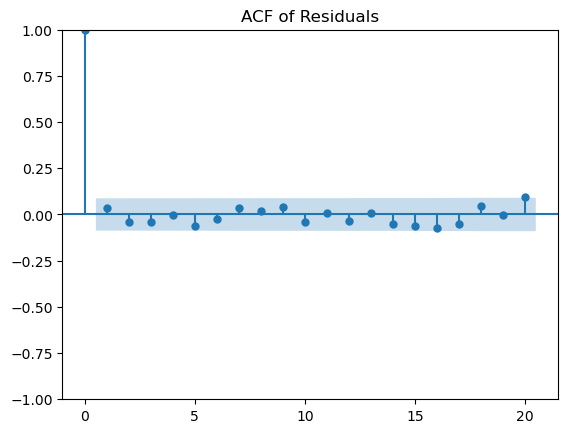

      lb_stat  lb_pvalue
10   6.992387   0.726164
20  21.097295   0.391426
const     0.000845
sigma2    0.000066
dtype: float64


In [33]:
##Fitting ARIMA Model##
from statsmodels.tsa.arima.model import ARIMA

y = df["log_return"]

model_0 = ARIMA(y, order=(0,0,0)).fit()
model_0.summary()

resid_0 = model_0.resid
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(resid_0)
plt.title("Residuals from Constant Mean Model")
plt.show()

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(resid_0, lags=20)
plt.title("ACF of Residuals")
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(resid_0, lags=[10,20], return_df=True)
print(lb_test)

print(model_0.params)

Check ACF of Squared Residuals

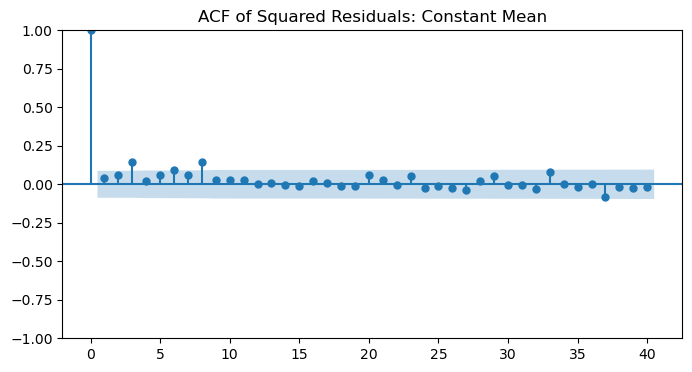

In [34]:
##ACF of Squared Residuals##
resid_0 = model_0.resid
plt.figure(figsize=(8,4))
plot_acf(resid_0**2, lags=40, ax=plt.gca())
plt.title("ACF of Squared Residuals: Constant Mean")
plt.show()

Fit Mean Models

In [35]:
# ==============================
# Fit candidate mean models
# ==============================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# Use log returns as the mean-model series
y = df["log_return"]

# Fit candidate models
model_0 = ARIMA(y, order=(0,0,0)).fit()      # Constant mean
model_1 = ARIMA(y, order=(1,0,0)).fit()      # AR(1)
model_ma1 = ARIMA(y, order=(0,0,1)).fit()    # MA(1)
model_ar2 = ARIMA(y, order=(2,0,0)).fit()    # AR(2)
model_ma2 = ARIMA(y, order=(0,0,2)).fit()    # MA(2)
model_arma21 = ARIMA(y, order=(2,0,1)).fit() # ARMA(2,1)
model_arma12 = ARIMA(y, order=(1,0,2)).fit() # ARMA(1,2)
model_arma22 = ARIMA(y, order=(2,0,2)).fit() # ARMA(2,2)

# Store all models in one dictionary
model_dict = {
    "ARIMA(0,0,0)": model_0,
    "AR(1)": model_1,
    "MA(1)": model_ma1,
    "AR(2)": model_ar2,
    "MA(2)": model_ma2,
    "ARMA(2,1)": model_arma21,
    "ARMA(1,2)": model_arma12,
    "ARMA(2,2)": model_arma22
}

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Compare Models

In [36]:
# ==============================
# Compare models using AIC and BIC
# ==============================

model_results = pd.DataFrame({
    "Model": list(model_dict.keys()),
    "AIC": [m.aic for m in model_dict.values()],
    "BIC": [m.bic for m in model_dict.values()]
})

model_results = model_results.sort_values("BIC").reset_index(drop=True)
model_results["AIC"] = model_results["AIC"].round(2)
model_results["BIC"] = model_results["BIC"].round(2)

print("Model comparison by AIC/BIC:")
print(model_results)

best_model_name = model_results.loc[0, "Model"]
best_model = model_dict[best_model_name]

print("\nBest model by BIC:", best_model_name)

Model comparison by AIC/BIC:
          Model      AIC      BIC
0  ARIMA(0,0,0) -3407.22 -3398.78
1         MA(1) -3405.84 -3393.18
2         AR(1) -3405.79 -3393.14
3         AR(2) -3404.66 -3387.79
4         MA(2) -3404.25 -3387.37
5     ARMA(2,1) -3404.42 -3383.32
6     ARMA(1,2) -3403.58 -3382.49
7     ARMA(2,2) -3401.77 -3376.46

Best model by BIC: ARIMA(0,0,0)


Fit AR(1) and Compare BIC/AIC; Check ACF of AR(1) Residuals

Constant mean AIC: -3407.2217104345864
AR(1) AIC: -3405.791015791762

Constant mean BIC: -3398.784510195203
AR(1) BIC: -3393.135215432687


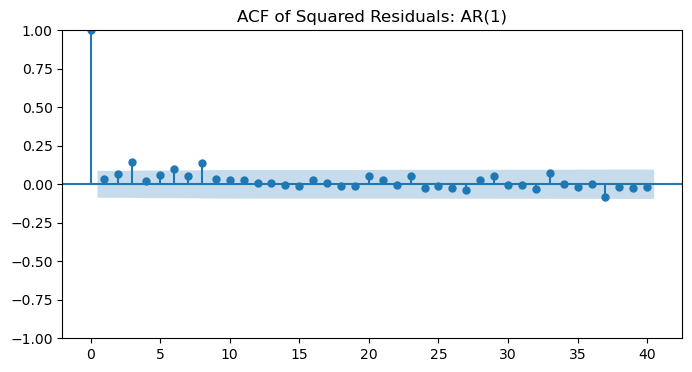

In [37]:
##Fit AR(1) and compare BIC/AIC##
from statsmodels.tsa.arima.model import ARIMA

y = df["log_return"]  # or use y if you already defined it

model_1 = ARIMA(y, order=(1,0,0)).fit()

print("Constant mean AIC:", model_0.aic)
print("AR(1) AIC:", model_1.aic)

print("\nConstant mean BIC:", model_0.bic)
print("AR(1) BIC:", model_1.bic)

##ACF of AR(1) Residuals##
resid_1 = model_1.resid
plt.figure(figsize=(8,4))
plot_acf(resid_1**2, lags=40, ax=plt.gca())
plt.title("ACF of Squared Residuals: AR(1)")
plt.show()

Check Significance of Constant Mean

In [17]:
## Check significance of constant mean (mu) in ARIMA(0,0,0) model ##
print(model_0.params)
from scipy import stats

# Extract mean (constant)
mu = model_0.params["const"]
se_mu = model_0.bse["const"]

t_stat = mu / se_mu
p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))   # large-sample z-test

print("\nConstant Mean Test (ARIMA(0,0,0))")
print(f"mu        = {mu:.8f}")
print(f"SE(mu)    = {se_mu:.8f}")
print(f"t-stat    = {t_stat:.4f}")
print(f"p-value   = {p_value:.6f}")

if abs(t_stat) >= 1.96:
    print("Result: Mean is statistically different from zero (5% level)")
else:
    print("Result: Mean is NOT statistically different from zero (cannot reject zero mean)")

const     0.000845
sigma2    0.000066
dtype: float64

Constant Mean Test (ARIMA(0,0,0))
mu        = 0.00084457
SE(mu)    = 0.00036657
t-stat    = 2.3040
p-value   = 0.021225
Result: Mean is statistically different from zero (5% level)


Build Table for Mean Model Comparison

Saved to: /Users/oliviadittrich/Desktop/spx_mean_model_comparison_aic_bic.png


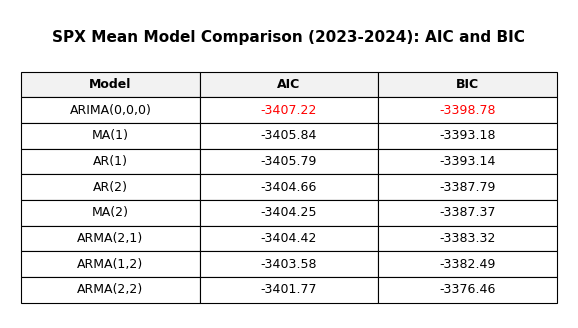

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Table for mean model comparison
model_table = model_results[["Model", "AIC", "BIC"]].copy()

fig, ax = plt.subplots(figsize=(7.2, 4.0))
fig.patch.set_facecolor("white")
ax.axis("off")

# Title
ax.text(
    0.5, 0.885,
    "SPX Mean Model Comparison (2023-2024): AIC and BIC",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    transform=ax.transAxes
)

# Table
table1 = ax.table(
    cellText=model_table.values,
    colLabels=model_table.columns,
    cellLoc="center",
    bbox=[0.02, 0.05, 0.96, 0.75]
)

table1.auto_set_font_size(False)
table1.set_fontsize(9)
table1.scale(1, 1.2)

for (row, col), cell in table1.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f2f2f2")

# Highlight ARIMA(0,0,0) AIC and BIC in red
arima_row = model_table.index[model_table["Model"] == "ARIMA(0,0,0)"][0] + 1
table1[(arima_row, 1)].get_text().set_color("red")  # AIC
table1[(arima_row, 2)].get_text().set_color("red")  # BIC

output_path = "/Users/oliviadittrich/Desktop/spx_mean_model_comparison_aic_bic.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.05)
print(f"Saved to: {output_path}")

plt.show()